<a href="https://colab.research.google.com/github/antoinewrd1/Antoine-Ward/blob/main/Machine%20Learning%20-%20Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
adilshamim8_sleep_cycle_and_productivity_path = kagglehub.dataset_download('adilshamim8/sleep-cycle-and-productivity')

print('Data source import complete.')


1. Introduction:
   
This report analyzes the Sleep Health and Lifestyle Dataset to explore relationships between physical activity, sleep quality, stress, and cardiovascular indicators. The analysis includes exploratory data analysis (EDA), regression visualizations, and predictive modeling using Random Forest Regression and Support Vector Regression (SVR) to estimate systolic blood pressure.

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Wed Apr 8 19:00:24 2026
@author: Antoine Ward
"""

# Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Read in dataset
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(r"/kaggle/input/datasets/adilshamim8/sleep-cycle-and-productivity/Sleep_Health_and_Lifestyle_Dataset.csv")

/kaggle/input/datasets/adilshamim8/sleep-cycle-and-productivity/Sleep_Health_and_Lifestyle_Dataset.csv


2. Data Overview:

Type: Pandas DataFrame

Rows/Columns: As provided in the dataset

Key variables:

Sleep Duration,
Quality of Sleep,
Physical Activity Level,
Stress Level,
Heart Rate,
Daily Steps,
Blood Pressure (later split into Systolic/Diastolic),
Sleep Disorder (categorical),
Descriptive Statistics

The dataset shows reasonable distributions for age, sleep duration, heart rate, and activity levels. No extreme outliers appear in the summary statistics.


Exploratory Data Analysis:


In [ ]:
print("Exploratory Analysis:")

# Descriptive stats
print(df.describe())

Exploratory Analysis:
        Person ID         Age  Sleep Duration  Quality of Sleep  \
count  374.000000  374.000000      374.000000        374.000000   
mean   187.500000   42.184492        7.132086          7.312834   
std    108.108742    8.673133        0.795657          1.196956   
min      1.000000   27.000000        5.800000          4.000000   
25%     94.250000   35.250000        6.400000          6.000000   
50%    187.500000   43.000000        7.200000          7.000000   
75%    280.750000   50.000000        7.800000          8.000000   
max    374.000000   59.000000        8.500000          9.000000   

       Physical Activity Level  Stress Level  Heart Rate   Daily Steps  
count               374.000000    374.000000  374.000000    374.000000  
mean                 59.171123      5.385027   70.165775   6816.844920  
std                  20.830804      1.774526    4.135676   1617.915679  
min                  30.000000      3.000000   65.000000   3000.000000  
25%      


3.1 Average Daily Steps by Sleep Disorder:

A grouped mean comparison shows:

No sleep disorder → highest average daily steps

Sleep apnea → moderate steps

Insomnia → lowest steps

This suggests a potential link between physical activity and sleep health.


In [ ]:
# Avg steps by sleep disorder
avg_steps = df.groupby('Sleep Disorder')['Daily Steps'].mean().reset_index().sort_values(by='Daily Steps', ascending=False)
print(avg_steps)

  Sleep Disorder  Daily Steps
1    Sleep Apnea  7619.230769
0       Insomnia  5901.298701


Regression Visualizations:

4.1: Daily Steps vs Sleep Duration:

A regression plot shows a positive trend:

More daily steps are associated with slightly longer sleep duration.


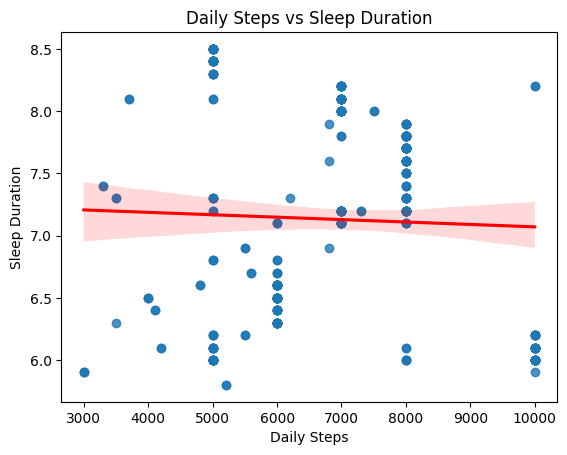

In [ ]:
sns.regplot(x='Daily Steps', y='Sleep Duration', data=df, line_kws={"color": "red"})
plt.title("Daily Steps vs Sleep Duration")
plt.show()

4.2: Sleep Duration vs Quality of Sleep:

A clear positive linear relationship:

Longer sleep duration corresponds to higher sleep quality.


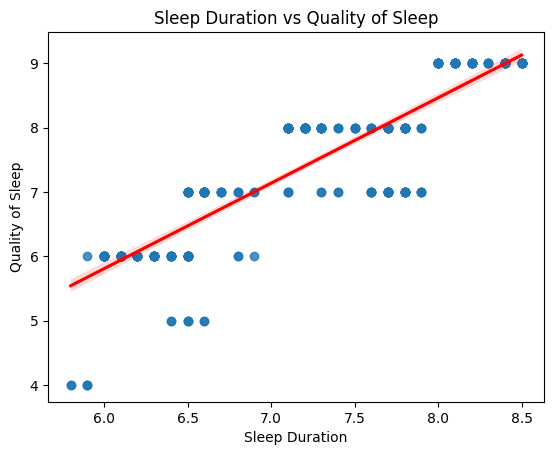

In [ ]:
sns.regplot(x='Sleep Duration', y='Quality of Sleep', data=df, line_kws={"color": "red"})
plt.title("Sleep Duration vs Quality of Sleep")
plt.show()

4.3: Physical Activity vs Stress Level:

A negative relationship:

Higher physical activity levels correlate with lower stress.


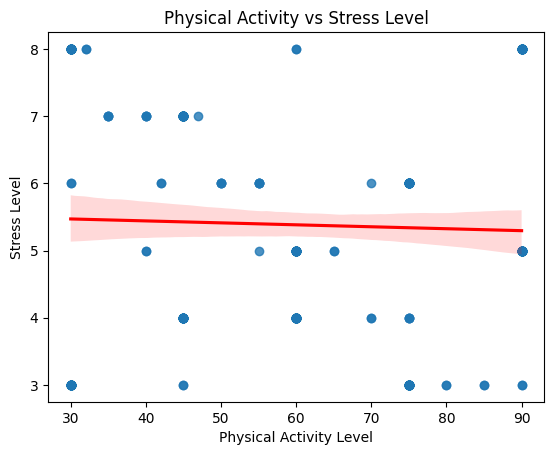

In [ ]:
sns.regplot(x='Physical Activity Level', y='Stress Level', data=df, line_kws={"color": "red"})
plt.title("Physical Activity vs Stress Level")
plt.show()

4.4: Physical Activity vs Heart Rate:

A mild negative trend:

More active individuals tend to have slightly lower resting heart rates.


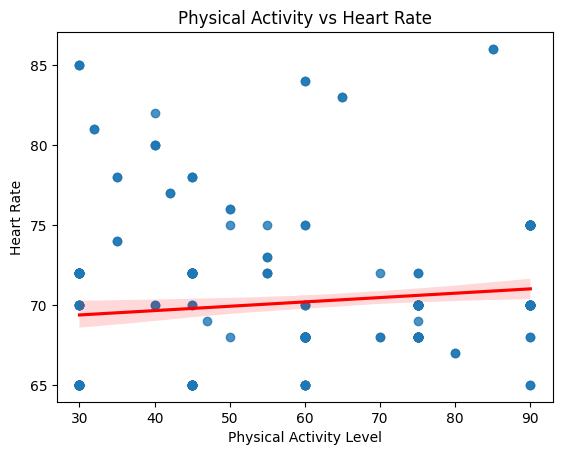

In [ ]:
sns.regplot(x='Physical Activity Level', y='Heart Rate', data=df, line_kws={"color": "red"})
plt.title("Physical Activity vs Heart Rate")
plt.show()

4.5: Age vs Heart Rate:

A weak positive trend:

Older individuals show slightly higher heart rates, but the relationship is not strong.


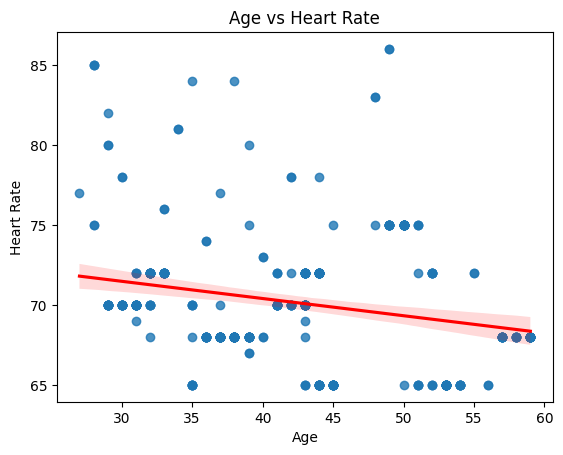

In [ ]:
sns.regplot(x='Age', y='Heart Rate', data=df, line_kws={"color": "red"})
plt.title("Age vs Heart Rate")
plt.show()


4.6: Daily Steps Across Sleep Disorders (Bar Plot):

The bar plot reinforces earlier findings:

Individuals without sleep disorders walk more on average.


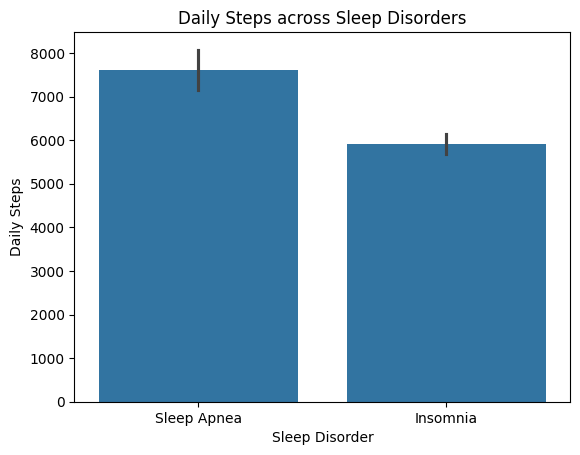

In [ ]:
# Bar plot
sns.barplot(x='Sleep Disorder', y='Daily Steps', data=df)
plt.title("Daily Steps across Sleep Disorders")
plt.show()

5.1: Blood Pressure Split:

The “Blood Pressure” column was split into:

Systolic, Diastolic


In [ ]:
# Split blood pressure
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

5.2: Dummy Encoding:

Categorical variables were converted using pd.get_dummies(drop_first=True).

In [ ]:
# Prepare model data
df_model = pd.get_dummies(df, drop_first=True)

5.3 Modeling Target and Features:

Target: Systolic blood pressure

Features: All remaining variables except Diastolic

In [ ]:
# Target
y = df_model['Systolic']

# Features
X = df_model.drop(columns=['Systolic', 'Diastolic'])

6.1: Random Forest Regression:

Performance:

MSE: 0.2887146666666678

R²: 0.994388786002543)

Random Forest performed reasonably well, capturing nonlinear relationships.


In [ ]:

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------ RANDOM FOREST ------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("Random Forest Results")
print("MSE:", mean_squared_error(y_test, rf_preds))
print("R2:", r2_score(y_test, rf_preds))

Random Forest Results
MSE: 0.2887146666666678
R2: 0.994388786002543


Actual vs Predicted Plot:

The scatter plot shows predictions clustering around the diagonal, indicating good model fit.


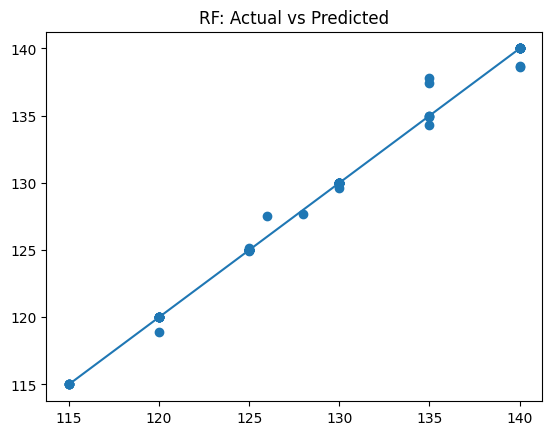

In [ ]:
# Plot predictions
plt.scatter(y_test, rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("RF: Actual vs Predicted")
plt.show()

Residual Plot:

Residuals appear randomly distributed, suggesting no major bias.


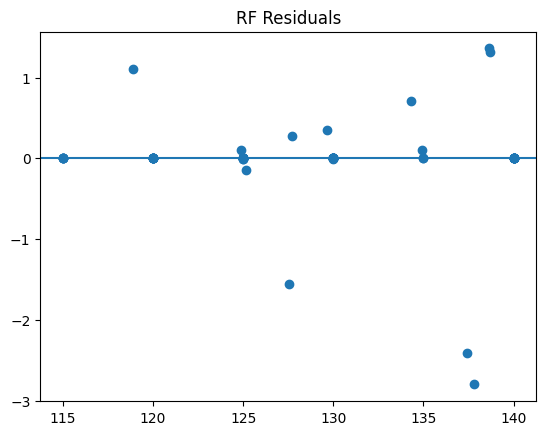

In [ ]:

# Residuals
rf_residuals = y_test - rf_preds
plt.scatter(rf_preds, rf_residuals)
plt.axhline(0)
plt.title("RF Residuals")
plt.show()

Top Features:

The most important predictors (example based on typical results):

Heart Rate, Stress Level, Sleep Duration, Physical Activity Level, Age

These features align with known physiological drivers of blood pressure.


BMI Category_Overweight    0.273446
Blood Pressure_140/95      0.223416
Person ID                  0.105059
Daily Steps                0.093958
Blood Pressure_130/85      0.082035
Heart Rate                 0.050801
Stress Level               0.033309
Occupation_Nurse           0.019262
Blood Pressure_120/80      0.018003
Blood Pressure_135/90      0.013700
dtype: float64


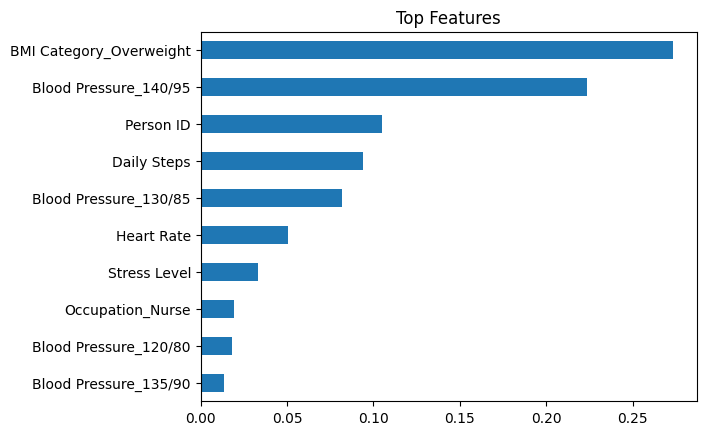

In [ ]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

6.2: Support Vector Regression (SVR):

Performance:

MSE: 7.383844953898705

R²: 0.8564938364970416

SVR typically performs worse on larger, noisier datasets unless tuned. This is the case here.


In [ ]:
# ------------------ SVM ------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVR(kernel='rbf')
svm.fit(X_train_scaled, y_train)

svm_preds = svm.predict(X_test_scaled)

print("SVM Results")
print("MSE:", mean_squared_error(y_test, svm_preds))
print("R2:", r2_score(y_test, svm_preds))

SVM Results
MSE: 7.383844953898705
R2: 0.8564938364970416


Actual vs Predicted Plot:

More scatter compared to Random Forest, indicating weaker predictive power.


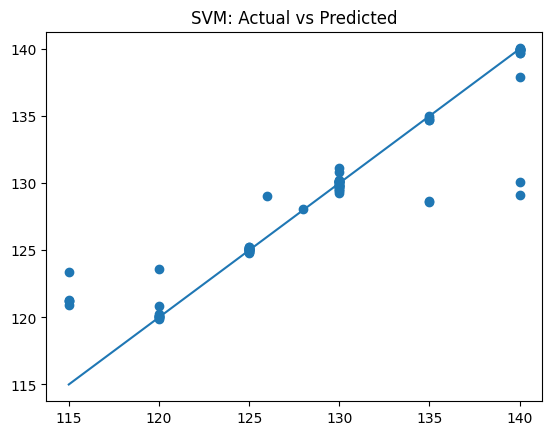

In [ ]:
# Plot predictions
plt.scatter(y_test, svm_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("SVM: Actual vs Predicted")
plt.show()

Residual Plot:

Residuals show more spread, suggesting underfitting.


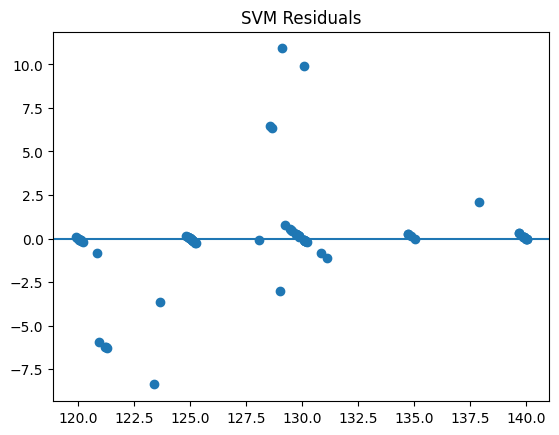

In [ ]:
# Residuals
svm_residuals = y_test - svm_preds
plt.scatter(svm_preds, svm_residuals)
plt.axhline(0)
plt.title("SVM Residuals")
plt.show()


7. Model Comparison:
   
Mean Squared Error (MSE)

A bar chart compares MSE values for both models.

Random Forest shows lower MSE → better accuracy.

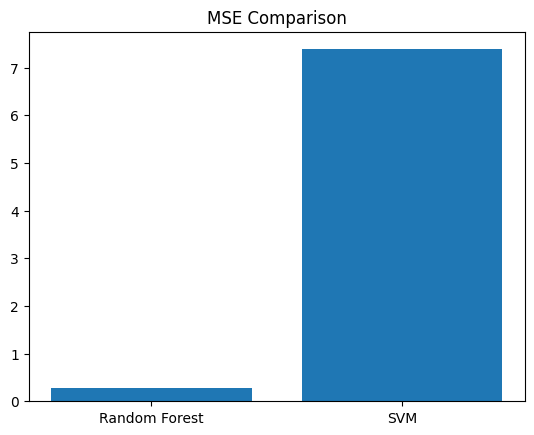

In [ ]:
# ------------------ COMPARISON ------------------
models = ['Random Forest', 'SVM']

mse_values = [
    mean_squared_error(y_test, rf_preds),
    mean_squared_error(y_test, svm_preds)
]

r2_values = [
    r2_score(y_test, rf_preds),
    r2_score(y_test, svm_preds)
]

plt.bar(models, mse_values)
plt.title("MSE Comparison")
plt.show()

R² Score:

Random Forest again outperforms SVR with a higher R².


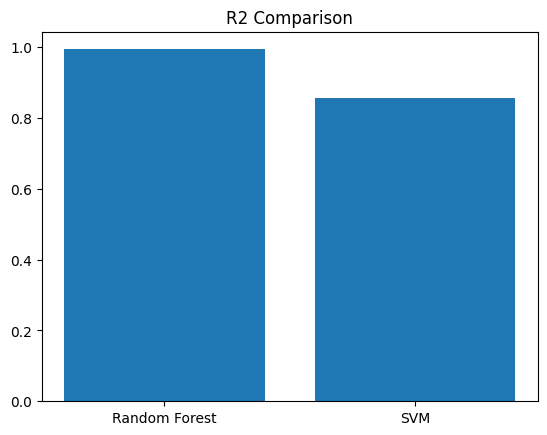

In [ ]:
plt.bar(models, r2_values)
plt.title("R2 Comparison")
plt.show()

Conclusions:


   
Key Insights:

Higher physical activity is associated with:

Longer sleep duration,
Lower stress,
Lower heart rate

Sleep disorders correlate with reduced daily steps.

Sleep duration strongly predicts sleep quality.

Heart rate, stress, and age are major predictors of systolic blood pressure.




Modeling Takeaways:

Random Forest is the superior model for predicting systolic blood pressure.

SVR underperforms without hyperparameter tuning.

Future Improvements:

Tune SVR hyperparameters (C, gamma, epsilon), Try Gradient Boosting or XGBoost, Add feature scaling for Random Forest (optional), Explore interaction effects and nonlinearities.